Entrenando Naive Bayes con 44391 mensajes...

REPORTE DE CLASIFICACIÓN (Métricas Unidad 1)
              precision    recall  f1-score   support

      Neutro       0.97      0.95      0.96      5577
      Tóxico       0.96      0.97      0.96      5521

    accuracy                           0.96     11098
   macro avg       0.96      0.96      0.96     11098
weighted avg       0.96      0.96      0.96     11098



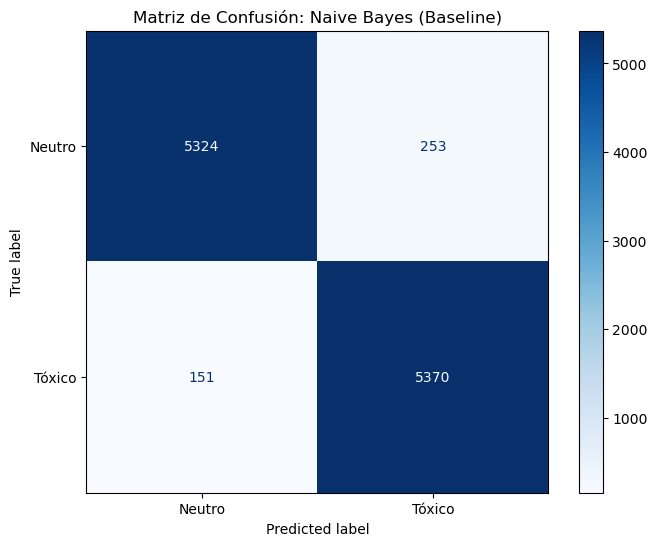


Mensaje: 'eres un bocachancla'
Predicción: TÓXICO (Probabilidad de toxicidad: 0.5007)

Mensaje: 'muchas gracias por la ayuda'
Predicción: NEUTRO (Probabilidad de toxicidad: 0.2485)


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. CARGA DE DATOS (Dataset ya limpio con tu función preferida)
df = pd.read_csv('DATASET_LIMPIO_PARA_MODELOS.csv')
# Aseguramos que no haya valores nulos tras la limpieza
df = df.dropna(subset=['texto_limpio'])

X = df['texto_limpio']
y = df['toxicidad']

# 2. REPRESENTACIÓN DE DATOS: TF-IDF (Unidad 1)
# Convertimos el texto en una matriz de pesos numéricos.
# Usamos unigramas y bigramas (ngram_range) para capturar contexto.
vectorizador = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_tfidf = vectorizador.fit_transform(X)

# 3. DIVISIÓN DEL DATASET (Unidad 1: Performance Assessment)
# Separamos un 20% para testear el modelo que la IA nunca ha visto.
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# 4. MODELO: Naive Bayes Multinomial (Unidad 2)
# Basado en la Regla de Bayes: P(Tóxico|Palabra)
print(f"Entrenando Naive Bayes con {X_train.shape[0]} mensajes...")
modelo_nb = MultinomialNB()
modelo_nb.fit(X_train, y_train)

# 5. EVALUACIÓN (Unidad 1)
y_pred = modelo_nb.predict(X_test)

print("\n" + "="*40)
print("REPORTE DE CLASIFICACIÓN (Métricas Unidad 1)")
print("="*40)
print(classification_report(y_test, y_pred, target_names=['Neutro', 'Tóxico']))

# 6. VISUALIZACIÓN: MATRIZ DE CONFUSIÓN (Unidad 1)
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Neutro', 'Tóxico'])
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Matriz de Confusión: Naive Bayes (Baseline)')
plt.savefig('matriz_confusion_nb.png') # Guardamos para tu TFG
plt.show()

# 7. PRUEBA ESPECÍFICA (Caso "Bocachancla")
def test_mensaje(msg):
    # Nota: Aquí deberías aplicar la función limpieza_profunda antes de transformar
    # pero para una prueba rápida usamos el vectorizador directo:
    msg_vec = vectorizador.transform([msg])
    pred = modelo_nb.predict(msg_vec)
    prob = modelo_nb.predict_proba(msg_vec)
    clase = "TÓXICO" if pred[0] == 1 else "NEUTRO"
    print(f"\nMensaje: '{msg}'")
    print(f"Predicción: {clase} (Probabilidad de toxicidad: {prob[0][1]:.4f})")

test_mensaje("eres un bocachancla")
test_mensaje("muchas gracias por la ayuda")

In [20]:
test_mensaje("ser feliz ")


Mensaje: 'ser feliz '
Predicción: TÓXICO (Probabilidad de toxicidad: 0.6088)
